# Fase 4 — Modelagem (ABT preditiva + baselines + modelos calibrados)

> **Metodologia:** CRISP-DM — *Modeling*
> **Projeto:** World Cup Analytics
> **Entrada:** `output/worldcup_dataset_clean.csv` (saída da Fase 3)

## A questão central: vazamento de dados (data leakage)

Para **prever** um jogo só podemos usar informação **disponível ANTES da partida**. As stats da
própria partida (xG, posse, rating *daquele* jogo) não existem antes do apito — usá-las é
**vazamento**: o modelo "trapaceia" olhando o futuro. A solução (confirmada na literatura):

1. **Forma recente (lagged):** cada stat vira a média das **últimas N partidas**, excluindo o
   jogo atual (`shift(1)`). Aqui usamos **N=10**.
2. **Elo dinâmico:** atualizado jogo a jogo (passada sequencial, só passado), com vantagem de
   mando **zerada em campo neutro** (Copa, Copa América, etc.).
3. **Validação TEMPORAL** (treinar no passado, testar no futuro; nunca embaralhar).

## Três melhorias desta versão

1. **Duas linhas por jogo (perspectiva de cada seleção).** Em vez de 1 linha "mandante − visitante"
   (que enviesa o alvo para 58% vitória do mandante), cada partida vira 2 linhas: *seleção A vs
   adversário* e *seleção B vs adversário*. O alvo fica **naturalmente balanceado** (~39% V /
   21% E / 39% D) e as features ficam orientadas pela ótica do time (não pelo mando) — mais
   natural para um torneio em campo neutro.
2. **Peso por importância do jogo (`sample_weight`).** Amistosos pesam 0.5, Copa do Mundo pesa
   3.0 — o modelo "presta mais atenção" nos jogos que importam, sem descartar dados.
3. **Head-to-Head histórico.** Para cada confronto, win rate e gols médios dos últimos 5
   encontros diretos entre as duas seleções (sempre `shift(1)` — só passado).

> **Métrica-alvo: log-loss** (probabilidade calibrada). Reportamos métricas em duas óticas:
> **por perspectiva** (tarefa balanceada de treino) e **por partida** (comparável ao baseline
> original de mando).

In [25]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, log_loss, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost nao instalado. Execute: uv add xgboost")

import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = (10, 5)
df = pd.read_csv(Path('../output/worldcup_dataset_clean.csv'), parse_dates=['match_date'])
df = df.sort_values('match_date').reset_index(drop=True)
print('Eventos:', len(df), '| periodo:', df.match_date.min().date(), '->', df.match_date.max().date())
print('Competicoes:', df['competition'].nunique() if 'competition' in df.columns else 'n/a', 'unicas')

Eventos: 1138 | periodo: 2023-06-17 -> 2026-06-21
Competicoes: 138 unicas


## 1–3. Forma recente (N=10, `shift(1)`) + Elo pré-jogo + importância do jogo

A tabela `tm` tem **1 linha por (time, jogo)** — ou seja, já são 2 linhas por partida (a ótica de
cada seleção). A forma é a média das últimas 10 **anteriores**; o Elo é a força acumulada
**antes** do jogo (vantagem de mando zerada em campo neutro). Guardamos também o `opponent` de
cada linha — usado adiante para anexar a forma do adversário e calcular o Head-to-Head.

In [26]:
ROLL = ['goals_for','goals_against','xg_for','xg_against','poss','rating','points','win']
N = 10

# ── pesos por importancia de competicao ───────────────────────────────────────
def competition_weight(comp):
    c = str(comp).lower()
    if 'world cup' in c and 'qualif' not in c: return 3.0
    if 'qualif' in c or 'eliminat' in c:       return 2.0
    if any(x in c for x in ['copa am','european championship',
                              'africa cup','asian cup','gold cup']): return 1.5
    if 'nations league' in c:                   return 1.5
    if 'friendly' in c or 'amistoso' in c:      return 0.5
    return 1.0

def is_neutral_venue(comp):
    """Copa do Mundo, Copa America, Euros etc. sao campo neutro — sem home advantage."""
    c = str(comp).lower()
    return int(any(x in c for x in ['world cup','copa am','european championship',
                                      'africa cup','asian cup','gold cup']))

if 'competition' in df.columns:
    df['match_importance'] = df['competition'].apply(competition_weight)
    df['is_neutral']       = df['competition'].apply(is_neutral_venue)
    print('Distribuicao de importancia (% de jogos):')
    print(df['match_importance'].value_counts(normalize=True).sort_index().map('{:.1%}'.format))
else:
    df['match_importance'] = 1.0; df['is_neutral'] = 0

# ── perspectivas (forma rolling) — 1 linha por (time, jogo) ───────────────────
def perspective(d, side):
    opp = 'away' if side=='home' else 'home'
    o = pd.DataFrame({'event_id': d['sofascore_event_id'], 'date': d['match_date'],
        'team': d[f'{side}_team'], 'opponent': d[f'{opp}_team'],
        'is_home': 1 if side=='home' else 0,
        'goals_for': d[f'score_{side}'], 'goals_against': d[f'score_{opp}'],
        'xg_for':    d.get(f'{side}_expected_goals'),
        'xg_against':d.get(f'{opp}_expected_goals'),
        'poss':      d.get(f'{side}_possession_pct'),
        'rating':    d.get(f'{side}_rating_mean')}
    )
    gd = o['goals_for'] - o['goals_against']
    o['points'] = np.where(gd>0, 3, np.where(gd==0, 1, 0))
    o['win']    = (gd>0).astype(int)
    return o

tm = pd.concat([perspective(df,'home'), perspective(df,'away')],
               ignore_index=True).sort_values(['team','date']).reset_index(drop=True)
g = tm.groupby('team', group_keys=False)
for c in ROLL:
    tm[f'form_{c}'] = g[c].apply(lambda s: s.shift(1).rolling(N, min_periods=1).mean())
tm['rest_days'] = g['date'].apply(lambda s: s.diff().dt.days)
tm['n_prev']    = tm.groupby('team').cumcount()

# ── Elo dinamico pre-jogo (HADV = 0 em campo neutro) ─────────────────────────
K, BASE, HADV_STD = 30, 1500.0, 40.0
elo = {}; ph = []; pa = []

for r in df.itertuples():
    hadv = 0.0 if getattr(r, 'is_neutral', 0) else HADV_STD
    rh, ra = elo.get(r.home_team, BASE), elo.get(r.away_team, BASE)
    ph.append(rh); pa.append(ra)
    eh  = 1 / (1 + 10**((ra - (rh + hadv)) / 400))
    gd  = r.score_home - r.score_away
    sh  = 1.0 if gd > 0 else (0.5 if gd == 0 else 0.0)
    elo[r.home_team] = rh + K * (sh - eh)
    elo[r.away_team] = ra + K * ((1-sh) - (1-eh))

df['home_elo'], df['away_elo'] = ph, pa
print('\nElo final (top 8):')
print(pd.Series(elo).sort_values(ascending=False).head(8).round(0))

Distribuicao de importancia (% de jogos):
match_importance
0.5    29.4%
1.0    11.6%
1.5    20.4%
2.0    23.4%
3.0    15.2%
Name: proportion, dtype: str

Elo final (top 8):
Morocco          1721.0
Spain            1709.0
Argentina        1689.0
Japan            1681.0
Germany          1667.0
France           1667.0
Côte d'Ivoire    1662.0
England          1652.0
dtype: float64


## 4–5. ABT longa (2 linhas/jogo) + Head-to-Head + split temporal

Cada partida vira **2 linhas** (ótica de cada seleção). Anexamos a forma do **adversário** por
self-join em `(event_id, opponent)`, calculamos as **diferenças orientadas pela ótica do time**
(`time − adversário`), o **Elo/ranking** de cada lado, e o **Head-to-Head** (últimos 5 confrontos
diretos). O split é **temporal** por data — as 2 linhas de um jogo têm a mesma data, então caem
sempre do mesmo lado (sem vazamento entre treino e teste).

In [27]:
# ── 1. forma do ADVERSARIO via self-join em (event_id, opponent) ──────────────
opp_cols = {f'form_{c}': f'opp_form_{c}' for c in ROLL}
opp_form = (tm[['event_id','team'] + [f'form_{c}' for c in ROLL] + ['rest_days']]
            .rename(columns={'team':'opponent', 'rest_days':'opp_rest_days', **opp_cols}))
L = tm.merge(opp_form, on=['event_id','opponent'], how='left')

# ── 2. resultado pela OTICA DO TIME (W/D/L) ──────────────────────────────────
gf, ga = L['goals_for'], L['goals_against']
L['result'] = np.where(gf > ga, 'W', np.where(gf == ga, 'D', 'L'))

# ── 3. Elo / ranking de cada lado (orientado pela otica do time) ─────────────
meta = (df[['sofascore_event_id','home_elo','away_elo',
            'home_team_ranking','away_team_ranking','match_importance','is_neutral']]
        .rename(columns={'sofascore_event_id':'event_id'}))
L = L.merge(meta, on='event_id', how='left')
L['elo']       = np.where(L.is_home==1, L.home_elo, L.away_elo)
L['opp_elo']   = np.where(L.is_home==1, L.away_elo, L.home_elo)
L['team_rank'] = np.where(L.is_home==1, L.home_team_ranking, L.away_team_ranking)
L['opp_rank']  = np.where(L.is_home==1, L.away_team_ranking, L.home_team_ranking)

# ── 4. Head-to-Head (ultimos 5 confrontos diretos, shift(1) = so passado) ─────
L = L.sort_values('date').reset_index(drop=True)
hk = L.groupby(['team','opponent'], group_keys=False)
L['h2h_n']       = hk.cumcount()
L['h2h_winrate'] = hk['win'].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
L['h2h_gf']      = hk['goals_for'].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
L['h2h_ga']      = hk['goals_against'].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())

# ── 5. diferencas (otica do time) ────────────────────────────────────────────
for c in ROLL:
    L[f'diff_form_{c}'] = L[f'form_{c}'] - L[f'opp_form_{c}']
L['elo_diff']  = L['elo'] - L['opp_elo']
L['rank_diff'] = L['opp_rank'] - L['team_rank']    # >0 = time melhor ranqueado
L['rest_diff'] = L['rest_days'] - L['opp_rest_days']

FEATURES = ([f'diff_form_{c}' for c in ROLL] +
            ['elo_diff','rank_diff','rest_diff','elo','opp_elo',
             'is_home','is_neutral','match_importance',
             'h2h_winrate','h2h_gf','h2h_ga','h2h_n'])

# ── 6. split TEMPORAL por data (2 linhas/jogo caem do mesmo lado) ─────────────
cut_date = df.sort_values('match_date').iloc[int(len(df)*0.75)]['match_date']
train = L[L.date <  cut_date].sort_values('date').reset_index(drop=True)
test  = L[L.date >= cut_date].sort_values('date').reset_index(drop=True)

print(f'ABT longa: {L.shape[0]} linhas (2 x {df.shape[0]} jogos) | {len(FEATURES)} features')
print(f'treino {len(train)} ({train.date.min().date()}..{train.date.max().date()}) | '
      f'teste {len(test)} ({test.date.min().date()}..{test.date.max().date()})')
print(f'\nAlvo (treino) — agora BALANCEADO: {dict(train["result"].value_counts().items())}')
print(f'  proporcoes: {train["result"].value_counts(normalize=True).round(3).to_dict()}')

ABT longa: 2276 linhas (2 x 1138 jogos) | 20 features
treino 1704 (2023-06-17..2025-11-15) | teste 572 (2025-11-15..2026-06-21)

Alvo (treino) — agora BALANCEADO: {'L': 673, 'W': 673, 'D': 358}
  proporcoes: {'L': 0.395, 'W': 0.395, 'D': 0.21}


## 6. Preparação dos dados + baselines (a régua)

**Prep único para todos os modelos:** imputação de mediana (cobre NaN de xG/posse em competições
menores) + padronização. Trees não precisam de escala, mas é monotônica — não atrapalha — e
permite passar `sample_weight` de forma uniforme a todos os modelos (sem `Pipeline`).

**`sample_weight` = balanceamento de classe × importância do jogo.** Em vez de `class_weight`
(que o XGBoost multiclasse não aceita), unificamos tudo num peso por amostra: classes raras (empate)
e jogos importantes (Copa) pesam mais.

Dois baselines: **por perspectiva** (alvo balanceado ~39/21/39) e **por partida** (ótica do
mandante — comparável ao baseline original 0.955).

In [28]:
from sklearn.preprocessing import LabelEncoder

# ── prep: impute (mediana) + scale, fit no treino ────────────────────────────
imputer = SimpleImputer(strategy='median').fit(train[FEATURES])
scaler  = StandardScaler().fit(imputer.transform(train[FEATURES]))
def prep(X): return scaler.transform(imputer.transform(X))

Xtr, ytr = prep(train[FEATURES]), train['result'].values
Xte, yte = prep(test[FEATURES]),  test['result'].values

# XGBoost exige alvo numerico → codificamos D/L/W em 0/1/2 (le.classes_ = ['D','L','W'])
le = LabelEncoder().fit(L['result'])
ytr_enc, yte_enc = le.transform(ytr), le.transform(yte)

# ── sample_weight = balanceamento de classe × importancia do jogo ─────────────
w_class = compute_sample_weight('balanced', ytr)
sw_tr   = w_class * train['match_importance'].values

# ── baseline POR PERSPECTIVA (alvo balanceado) ────────────────────────────────
labels = sorted(np.unique(ytr))
freq   = pd.Series(ytr).value_counts(normalize=True).reindex(labels).values
ll_freq_persp = log_loss(yte, np.tile(freq, (len(yte),1)), labels=labels)
acc_maj_persp = pd.Series(yte).value_counts(normalize=True).max()
print('--- POR PERSPECTIVA (tarefa de treino, balanceada) ---')
print(f'BASELINE classe majoritaria : acc={acc_maj_persp:.3f}')
print(f'BASELINE log-loss (freq)    : {ll_freq_persp:.3f}')

# ── baseline POR PARTIDA (otica do mandante — comparavel ao original) ─────────
test_home  = test[test.is_home == 1]
ytr_home   = train[train.is_home == 1]['result'].values
freq_home  = pd.Series(ytr_home).value_counts(normalize=True).reindex(labels).values
yte_home   = test_home['result'].values
yte_home_enc = le.transform(yte_home)
ll_freq_match  = log_loss(yte_home, np.tile(freq_home, (len(yte_home),1)), labels=labels)
acc_maj_match  = (yte_home == 'W').mean()
print('\n--- POR PARTIDA (otica do mandante, comparavel ao baseline 0.955) ---')
print(f'BASELINE sempre-mandante : acc={acc_maj_match:.3f}')
print(f'BASELINE log-loss (freq) : {ll_freq_match:.3f}')

--- POR PERSPECTIVA (tarefa de treino, balanceada) ---
BASELINE classe majoritaria : acc=0.392
BASELINE log-loss (freq)    : 1.066

--- POR PARTIDA (otica do mandante, comparavel ao baseline 0.955) ---
BASELINE sempre-mandante : acc=0.517
BASELINE log-loss (freq) : 1.028


## 7. Comparação Multi-Modelo (com `sample_weight`)

4 modelos calibrados (`TimeSeriesSplit(3)`), todos treinados com o mesmo `sample_weight`
(balanceamento × importância do jogo).

| Modelo | Notas |
|--------|-------|
| **Logistic Regression** | Baseline linear interpretável |
| **Random Forest** | Ensemble robusto, menos overfit |
| **HistGradientBoosting** | Boosting nativo do sklearn |
| **XGBoost** | Referência de competições Kaggle |

Métricas reportadas **por perspectiva** (tarefa balanceada). O `delta` é vs. o baseline de
frequência por perspectiva.

In [29]:
PALETA = {'Logistic Regression':'#2a9d8f', 'Random Forest':'#e76f51',
          'HistGradientBoosting':'#264653', 'XGBoost':'#f4a261'}

models_def = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8,
                                            min_samples_leaf=5, random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05,
                                                           max_iter=300, l2_regularization=2.0,
                                                           random_state=42),
}
if HAS_XGB:
    models_def['XGBoost'] = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          min_child_weight=5, random_state=42, verbosity=0)

home_mask = (test.is_home == 1).values   # 1 linha por partida (otica do mandante)

results = {}; trained_models = {}
print(f'{"Modelo":<22} {"log_loss":>9} {"delta":>8} {"acc":>6} {"f1_mac":>7}  | por-PARTIDA ll/acc')
print('-' * 78)
for name, clf in models_def.items():
    cal = CalibratedClassifierCV(clf, method='sigmoid', cv=TimeSeriesSplit(3))
    cal.fit(Xtr, ytr_enc, sample_weight=sw_tr)
    p    = cal.predict_proba(Xte)                    # colunas na ordem le.classes_ = D,L,W
    pred = le.inverse_transform(cal.predict(Xte))    # de volta para strings
    ll   = log_loss(yte_enc, p, labels=cal.classes_)
    acc  = accuracy_score(yte, pred)
    f1   = f1_score(yte, pred, average='macro')
    # por partida (otica do mandante)
    ll_m  = log_loss(yte_home_enc, p[home_mask], labels=cal.classes_)
    acc_m = accuracy_score(yte_home, pred[home_mask])
    results[name] = dict(log_loss=ll, accuracy=acc, f1_macro=f1, pred=pred, proba=p,
                         classes=le.classes_, ll_match=ll_m, acc_match=acc_m)
    trained_models[name] = cal
    icon = 'OK' if ll < ll_freq_persp else 'XX'
    print(f'[{icon}] {name:<18} {ll:>9.4f} {ll-ll_freq_persp:>+8.4f} {acc:>6.3f} {f1:>7.3f}'
          f'  | {ll_m:.4f} / {acc_m:.3f}')

print(f'\nBaseline por-perspectiva: ll={ll_freq_persp:.4f} | Baseline por-partida: ll={ll_freq_match:.4f}')

Modelo                  log_loss    delta    acc  f1_mac  | por-PARTIDA ll/acc
------------------------------------------------------------------------------
[OK] Logistic Regression    0.9095  -0.1563  0.575   0.543  | 0.9101 / 0.573
[OK] Random Forest         0.9035  -0.1624  0.535   0.530  | 0.9055 / 0.535
[OK] HistGradientBoosting    0.8991  -0.1667  0.582   0.521  | 0.9012 / 0.587
[OK] XGBoost               0.8949  -0.1709  0.572   0.531  | 0.8954 / 0.566

Baseline por-perspectiva: ll=1.0658 | Baseline por-partida: ll=1.0284


## 8. Métricas — tabela comparativa e visual

**Log-loss**: quanto menor, melhor. Casas de apostas chegam a ~0.65–0.70 (benchmark real).
**Accuracy**: % de acertos de classe — enganosa sozinha; o modelo pode acertar só vitórias.
**F1 macro**: média do F1 de cada classe — revela se o modelo prevê empates e derrotas.

                      log_loss  accuracy  f1_macro  ll_match  acc_match
XGBoost                 0.8949    0.5717    0.5311    0.8954     0.5664
HistGradientBoosting    0.8991    0.5822    0.5209    0.9012     0.5874
Random Forest           0.9035    0.5350    0.5300    0.9055     0.5350
Logistic Regression     0.9095    0.5752    0.5425    0.9101     0.5734
BASELINE (freq)         1.0658    0.3916       NaN    1.0284     0.5175


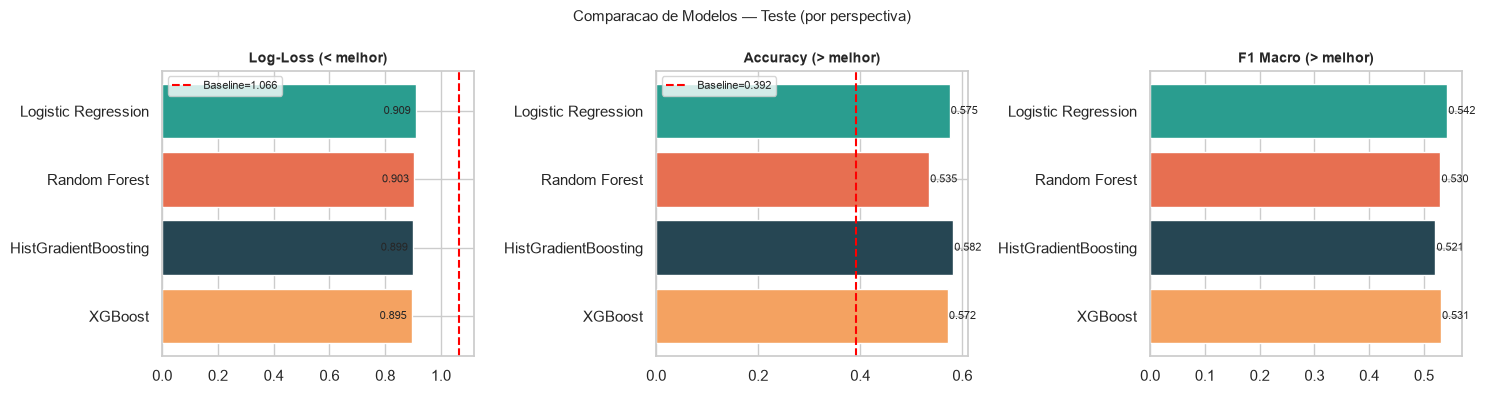


Melhor modelo (menor log-loss): XGBoost


In [30]:
# ── tabela de resultados ──────────────────────────────────────────────────────
df_res = pd.DataFrame(
    {n: {k: r[k] for k in ('log_loss','accuracy','f1_macro','ll_match','acc_match')}
     for n, r in results.items()}
).T
df_res.loc['BASELINE (freq)'] = dict(log_loss=ll_freq_persp, accuracy=acc_maj_persp,
                                     f1_macro=float('nan'),
                                     ll_match=ll_freq_match, acc_match=acc_maj_match)
df_res = df_res.sort_values('log_loss').round(4)
print(df_res.to_string())

# ── grafico de barras comparativo ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metricas = ['log_loss',           'accuracy',           'f1_macro']
titulos  = ['Log-Loss (< melhor)', 'Accuracy (> melhor)', 'F1 Macro (> melhor)']

for ax, met, tit in zip(axes, metricas, titulos):
    nomes = [n for n in df_res.index if n != 'BASELINE (freq)']
    vals  = [df_res.loc[n, met] for n in nomes]
    cores = [PALETA.get(n,'#aaa') for n in nomes]
    ax.barh(nomes, vals, color=cores)
    base_val = df_res.loc['BASELINE (freq)', met]
    if not pd.isna(base_val):
        ax.axvline(base_val, color='red', linestyle='--', lw=1.5, label=f'Baseline={base_val:.3f}')
        ax.legend(fontsize=8)
    ax.set_title(tit, fontsize=10, fontweight='bold')
    for i, v in enumerate(vals):
        ax.text(v * 0.98 if met=='log_loss' else v + 0.002, i, f'{v:.3f}',
                va='center', ha='right' if met=='log_loss' else 'left', fontsize=8)

plt.suptitle('Comparacao de Modelos — Teste (por perspectiva)', fontsize=11)
plt.tight_layout(); plt.show()
print('\nMelhor modelo (menor log-loss):', min(results, key=lambda n: results[n]['log_loss']))

A linha vermelha tracejada é o **baseline de frequência por perspectiva** (~39/21/39). Como o alvo
agora é balanceado, a acurácia da classe majoritária caiu para ~0.39 (não mais 0.60) — então
números de acurácia **não são comparáveis** com a versão antiga de 1 linha/jogo. Use a coluna
`acc_match` / `ll_match` da tabela para comparar com o baseline original por partida (0.955).

**F1 macro** subindo acima de ~0.33 indica que o modelo realmente distingue as 3 classes.

## 9. Matrizes de Confusão

Linhas = classe real; colunas = classe prevista. Diagonal = acertos.
Erros frequentes revelam onde cada modelo falha sistematicamente:
- Muitos D previstos como W → modelo não distingue empate de vitória
- Muitos L previstos como W → modelo não percebe fraqueza do mandante

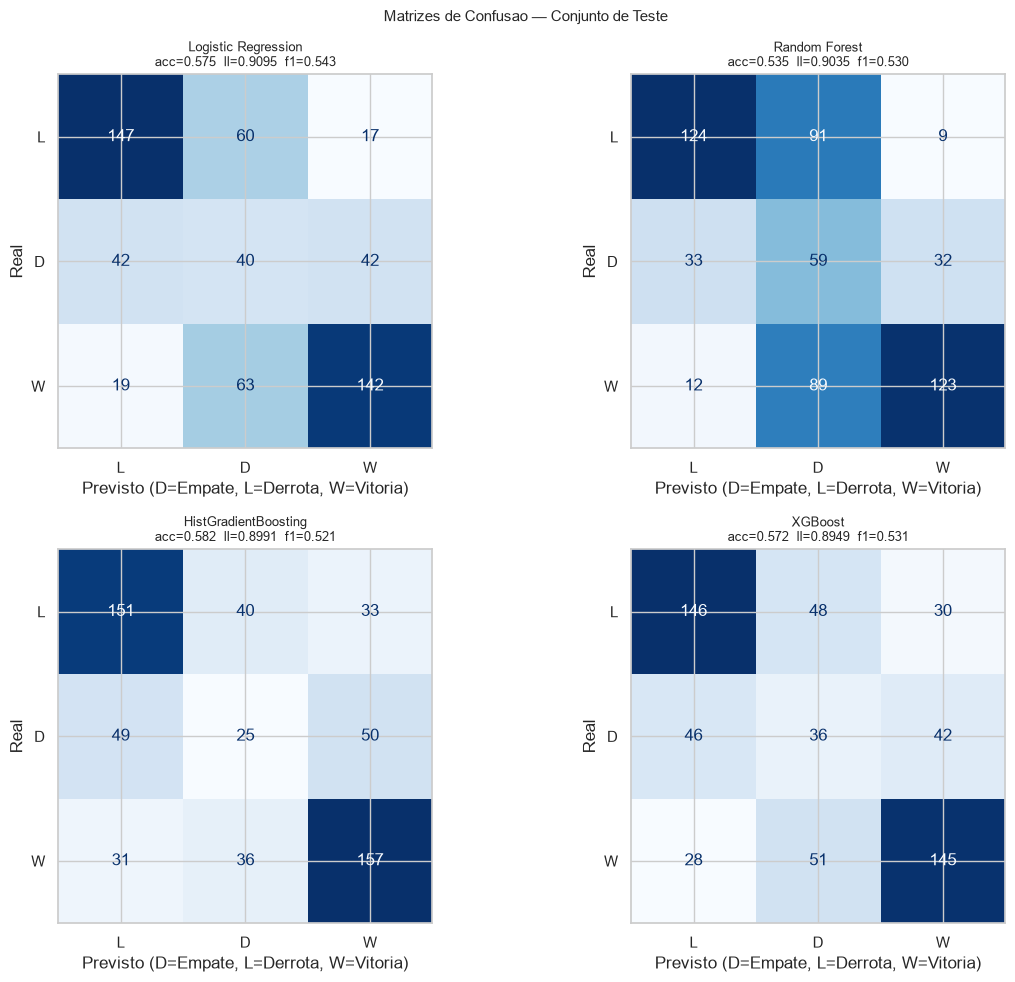


Classification Report — XGBoost:
              precision    recall  f1-score   support

  D (Empate)       0.27      0.29      0.28       124
 L (Derrota)       0.66      0.65      0.66       224
 W (Vitoria)       0.67      0.65      0.66       224

    accuracy                           0.57       572
   macro avg       0.53      0.53      0.53       572
weighted avg       0.58      0.57      0.58       572



In [31]:
n_models = len(results)
ncols = 2; nrows = (n_models + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes_flat = axes.flatten() if n_models > 1 else [axes]
class_order = ['L','D','W']

for i, (name, r) in enumerate(results.items()):
    cm   = confusion_matrix(yte, r['pred'], labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=axes_flat[i], colorbar=False, cmap='Blues')
    axes_flat[i].set_title(
        f'{name}\nacc={r["accuracy"]:.3f}  ll={r["log_loss"]:.4f}  f1={r["f1_macro"]:.3f}',
        fontsize=9)
    axes_flat[i].set_xlabel('Previsto (D=Empate, L=Derrota, W=Vitoria)')
    axes_flat[i].set_ylabel('Real')

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Matrizes de Confusao — Conjunto de Teste', fontsize=11)
plt.tight_layout(); plt.show()

# ── classification report do melhor modelo ───────────────────────────────────
best_name = min(results, key=lambda n: results[n]['log_loss'])
print(f'\nClassification Report — {best_name}:')
print(classification_report(yte, results[best_name]['pred'],
                             target_names=['D (Empate)','L (Derrota)','W (Vitoria)']))

## 10. Curvas de Calibração, Importância de Features e Validação Temporal

**Calibração**: uma curva próxima à diagonal significa que as probabilidades são confiáveis
(quando o modelo diz 70%, o time realmente ganha ~70% das vezes).
**Importância por permutação**: queda no log-loss ao embaralhar cada feature — maior = mais importante.

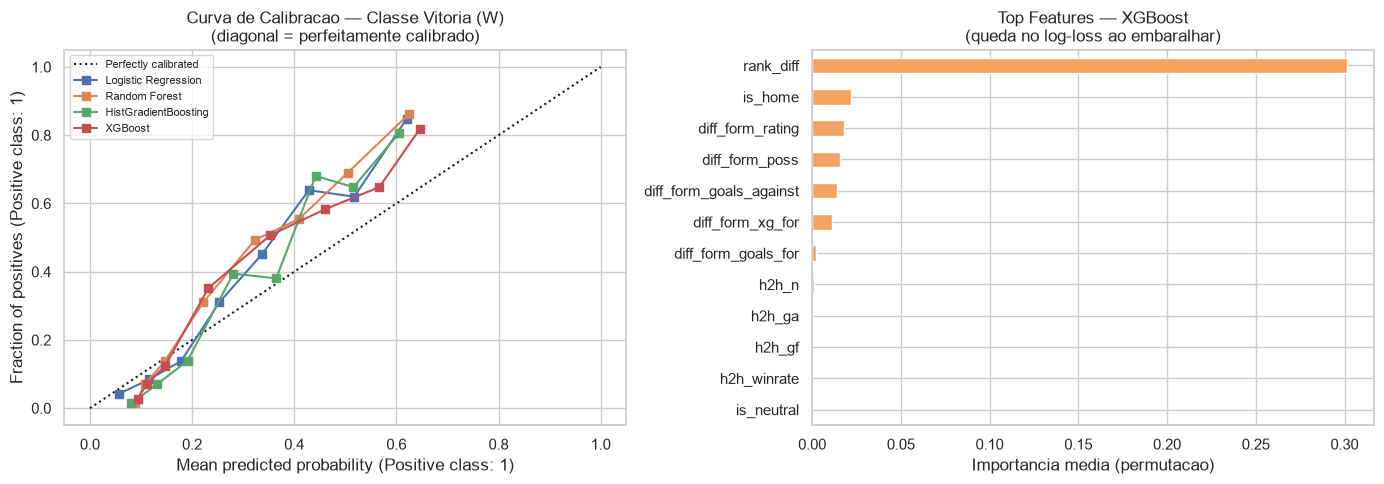


Validacao temporal (TimeSeriesSplit 5 blocos) — log-loss medio:
Modelo                       Media     Std      Min      Max
----------------------------------------------------------
Logistic Regression         0.9154  0.0445   0.8590   0.9648
Random Forest               0.9140  0.0319   0.8739   0.9596
HistGradientBoosting        0.9154  0.0212   0.8887   0.9498
XGBoost                     0.9187  0.0337   0.8840   0.9680


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── curvas de calibracao (classe W) ──────────────────────────────────────────
ax_cal = axes[0]
for name, r in results.items():
    cls_list = list(r['classes'])
    if 'W' in cls_list:
        p_w = r['proba'][:, cls_list.index('W')]
        y_w = (yte == 'W').astype(int)
        CalibrationDisplay.from_predictions(y_w, p_w, n_bins=8, ax=ax_cal,
                                             name=name, strategy='quantile')
ax_cal.set_title('Curva de Calibracao — Classe Vitoria (W)\n(diagonal = perfeitamente calibrado)')
ax_cal.legend(fontsize=8)

# ── importancia por permutacao (melhor modelo) ────────────────────────────────
ax_imp = axes[1]
best_name = min(results, key=lambda n: results[n]['log_loss'])
imp = permutation_importance(trained_models[best_name], Xte, yte_enc,
                             n_repeats=15, random_state=42, scoring='neg_log_loss')
imp_s = (pd.Series(imp.importances_mean, index=FEATURES)
           .sort_values(ascending=False).head(12))
imp_s.iloc[::-1].plot.barh(ax=ax_imp, color=PALETA.get(best_name,'#264653'))
ax_imp.set_title(f'Top Features — {best_name}\n(queda no log-loss ao embaralhar)')
ax_imp.set_xlabel('Importancia media (permutacao)')
plt.tight_layout(); plt.show()

# ── validacao temporal (5 splits) — prep + sample_weight por fold ─────────────
print('\nValidacao temporal (TimeSeriesSplit 5 blocos) — log-loss medio:')
tscv = TimeSeriesSplit(n_splits=5); ts_lls = {n: [] for n in models_def}
Ls = L.sort_values('date').reset_index(drop=True)

for tr_i, te_i in tscv.split(Ls):
    tr, te = Ls.iloc[tr_i], Ls.iloc[te_i]
    imp_f = SimpleImputer(strategy='median').fit(tr[FEATURES])
    sc_f  = StandardScaler().fit(imp_f.transform(tr[FEATURES]))
    Xtr_f, Xte_f = sc_f.transform(imp_f.transform(tr[FEATURES])), sc_f.transform(imp_f.transform(te[FEATURES]))
    ytr_f, yte_f = le.transform(tr['result']), le.transform(te['result'])
    sw_f = compute_sample_weight('balanced', ytr_f) * tr['match_importance'].values
    for name, clf in models_def.items():
        c = CalibratedClassifierCV(clf, method='sigmoid', cv=TimeSeriesSplit(3))
        c.fit(Xtr_f, ytr_f, sample_weight=sw_f)
        ts_lls[name].append(log_loss(yte_f, c.predict_proba(Xte_f), labels=c.classes_))

print(f'{"Modelo":<25}  {"Media":>7}  {"Std":>6}  {"Min":>7}  {"Max":>7}')
print('-' * 58)
for name, lls in ts_lls.items():
    print(f'{name:<25}  {np.mean(lls):>7.4f}  {np.std(lls):>6.4f}  {np.min(lls):>7.4f}  {np.max(lls):>7.4f}')

### Conclusão e próximos passos

**O que mudou nesta versão:**
- **Duas linhas por jogo** (ótica de cada seleção) → alvo balanceado (~39/21/39), features
  orientadas pelo time e não pelo mando, e o dobro de linhas de treino.
- **`sample_weight` = balanceamento × importância do jogo** → o modelo foca em Copa/eliminatórias
  e trata o empate (classe rara) com mais peso.
- **Head-to-Head** (win rate e gols dos últimos 5 confrontos diretos) como novas features.

**Como ler os resultados:**
- **Por perspectiva** (headline): tarefa balanceada; F1 macro agora é informativo.
- **Por partida** (`ll_match`/`acc_match`): comparável ao baseline original 0.955 / 0.596.
- A **validação temporal (5 blocos)** confirma se o ganho é estável no tempo, não sorte do split.

**Para ganhar mais (próximas fases):**
1. **Ensemble** das probabilidades dos melhores modelos (média) — costuma reduzir log-loss.
2. **Simetrização** da previsão por partida: média de P(time A) com P(time B) invertido.
3. **Tuning do Elo** (K=20 Copa, K=15 amistoso) — mais estável para seleções.
4. **Odds de mercado** como feature/baseline — sinal mais forte disponível, se coletável.
5. **Exportar previsões** (probabilidades por confronto) para Excel — entrega final do projeto.